In [30]:
import pandas as pd
import numpy as np
import time
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from feature_engineer import get_engineered_df
warehouses = ["OE", "OF"]
work_codes = ["10", "20", "30"]
max_time = 300
min_train_days = 3
all_results = []

In [31]:
# DATA_PATH = f"~/Lucas_Systems_Capstone_Project/data/processed/oe_detailed.parquet"
# df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse='OE', work_code='30', max_time=max_time)

In [ ]:
for wh in warehouses:
    DATA_PATH = f"~/Lucas_Systems_Capstone_Project/data/processed/{wh.lower()}_detailed.parquet"
    
    for wc in work_codes:
        print(f"\n--- Processing {wh} | WorkCode {wc} ---")
        
        # 1. Load and Engineer Features
        # Assuming get_engineered_df returns a 'Date' or 'Start_Time' column
        df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse=wh, work_code=wc, max_time=max_time)
        
        df['Date'] = pd.to_datetime(df['Timestamp']).dt.date
        df = df.sort_values('Timestamp') # Sort chronologically
        
        unique_dates = sorted(df['Date'].unique())        

        # 2. Iterative Time Splits (Expanding Window)
        for i in range(min_train_days, len(unique_dates)):
            train_dates = unique_dates[:i]
            test_date = unique_dates[i]
            
            print(f"  Split {i-min_train_days+1}: Training through {train_dates[-1]} | Testing on {test_date}")
            
            train_df = df[df['Date'].isin(train_dates)]
            test_df = df[df['Date'] == test_date]
            
            # Scenarios: With Distance vs Without Distance (getting rid of efficient_user)
            scenarios = {
                "With Distance": {
                    "features": [f for f in features if f != "efficient_user"],
                    "cat_cols": [c for c in cat_cols if c != "efficient_user"]
                },
                "Without Distance": {
                    "features": [f for f in features if f not in ["Travel_Distance", "same_aisle", "same_lockey", "diff_level", "efficient_user"]],
                    "cat_cols": [c for c in cat_cols if c not in ["same_aisle", "same_lockey", "diff_level", "efficient_user"]]
                }
            }
            
            for name, config in scenarios.items():
                # Prepare X and y
                # We use get_dummies on the subset to avoid data leakage 
                # (though in this context, we align columns to match)
                X_train = pd.get_dummies(train_df[config['features']], columns=config['cat_cols'], drop_first=True)
                y_train = train_df["Time_Delta_sec"]
                
                X_test = pd.get_dummies(test_df[config['features']], columns=config['cat_cols'], drop_first=True)
                y_test = test_df["Time_Delta_sec"]
                
                # Align columns between train and test (handling missing dummy categories)
                X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
                
                # 3. Model Training (reduced max_depth from 6 to 3, changed objective from default to absolute error, added a min child weight)
                model = XGBRegressor(
                    objective='reg:absoluteerror', 
                    n_estimators=1000, 
                    learning_rate=0.05, 
                    max_depth=3, 
                    min_child_weight=5, 
                    random_state=42, 
                    n_jobs=-1
                )

                model.fit(X_train, y_train)      

                # 4. Evaluation
                preds = model.predict(X_test)
                r2 = r2_score(y_test, preds)
                mae = mean_absolute_error(y_test, preds)
                
                # 5. Store Results
                all_results.append({
                    "Warehouse": wh,
                    "WorkCode": wc,
                    "Scenario": name,
                    "Train_End_Date": train_dates[-1],
                    "Test_Date": test_date,
                    "Train_Days_Count": len(train_dates),
                    "Train_Rows": len(X_train),
                    "Test_Rows": len(X_test),
                    "R^2": round(r2, 4),
                    "MAE": round(mae, 2)
                })

# 6. Display Results
results_df = pd.DataFrame(all_results)
display(results_df)


--- Processing OE | WorkCode 10 ---
  Split 1: Training through 2025-11-10 | Testing on 2025-11-11
  Split 2: Training through 2025-11-11 | Testing on 2025-11-12
  Split 3: Training through 2025-11-12 | Testing on 2025-11-13
  Split 4: Training through 2025-11-13 | Testing on 2025-12-01
  Split 5: Training through 2025-12-01 | Testing on 2025-12-02

--- Processing OE | WorkCode 20 ---
  Split 1: Training through 2025-11-10 | Testing on 2025-11-11
  Split 2: Training through 2025-11-11 | Testing on 2025-11-12
  Split 3: Training through 2025-11-12 | Testing on 2025-11-13
  Split 4: Training through 2025-11-13 | Testing on 2025-12-01
  Split 5: Training through 2025-12-01 | Testing on 2025-12-02

--- Processing OE | WorkCode 30 ---
  Split 1: Training through 2025-11-10 | Testing on 2025-11-11
  Split 2: Training through 2025-11-11 | Testing on 2025-11-12
  Split 3: Training through 2025-11-12 | Testing on 2025-11-13
  Split 4: Training through 2025-11-13 | Testing on 2025-12-01
  Split

,Warehouse,WorkCode,Scenario,Train_End_Date,Test_Date,Train_Days_Count,Train_Rows,Test_Rows,R^2,MAE
0,OE,10,With Distance,2025-11-10,2025-11-11,3,1625,563,0.3260,32.22
1,OE,10,Without Distance,2025-11-10,2025-11-11,3,1625,563,0.1211,38.87
2,OE,10,With Distance,2025-11-11,2025-11-12,4,2188,483,0.2194,36.30
3,OE,10,Without Distance,2025-11-11,2025-11-12,4,2188,483,-0.1077,45.97
4,OE,10,With Distance,2025-11-12,2025-11-13,5,2671,427,0.2972,31.12
5,OE,10,Without Distance,2025-11-12,2025-11-13,5,2671,427,0.0259,38.38
6,OE,10,With Distance,2025-11-13,2025-12-01,6,3098,501,0.3051,34.33
7,OE,10,Without Distance,2025-11-13,2025-12-01,6,3098,501,0.0037,43.84
8,OE,10,With Distance,2025-12-01,2025-12-02,7,3599,483,0.2720,39.84
9,OE,10,Without Distance,2025-12-01,2025-12-02,7,3599,483,0.0686,46.96


In [33]:
pd.set_option('display.max_rows', None)
display(results_df)

,Warehouse,WorkCode,Scenario,Train_End_Date,Test_Date,Train_Days_Count,Train_Rows,Test_Rows,R^2,MAE
0,OE,10,With Distance,2025-11-10,2025-11-11,3,1625,563,0.3260,32.22
1,OE,10,Without Distance,2025-11-10,2025-11-11,3,1625,563,0.1211,38.87
2,OE,10,With Distance,2025-11-11,2025-11-12,4,2188,483,0.2194,36.30
3,OE,10,Without Distance,2025-11-11,2025-11-12,4,2188,483,-0.1077,45.97
4,OE,10,With Distance,2025-11-12,2025-11-13,5,2671,427,0.2972,31.12
5,OE,10,Without Distance,2025-11-12,2025-11-13,5,2671,427,0.0259,38.38
6,OE,10,With Distance,2025-11-13,2025-12-01,6,3098,501,0.3051,34.33
7,OE,10,Without Distance,2025-11-13,2025-12-01,6,3098,501,0.0037,43.84
8,OE,10,With Distance,2025-12-01,2025-12-02,7,3599,483,0.2720,39.84
9,OE,10,Without Distance,2025-12-01,2025-12-02,7,3599,483,0.0686,46.96


In [36]:
# Save to CSV for persistent tracking
results_df.to_csv("time_split_results.csv", index=False)

/var/folders/r9/zx84vhy57q9_n8tk5dnw8g980000gn/T/ipykernel_76123/3347147717.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_df = results_df[results_df['Scenario'] == 'With Distance'][results_df["Warehouse"] == 'OE'].copy()


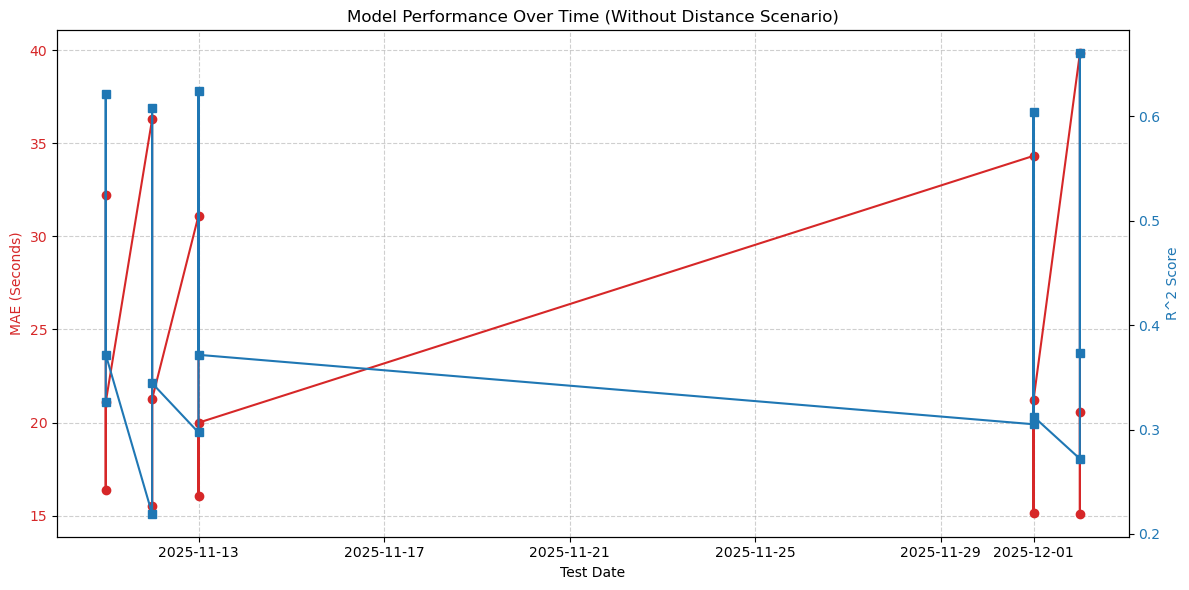

In [37]:
import matplotlib.pyplot as plt

# Filter for the "Without Distance" scenario
plot_df = results_df[results_df['Scenario'] == 'With Distance'][results_df["Warehouse"] == 'OE'].copy()

# Sort by the test date to ensure a chronological line
plot_df = plot_df.sort_values('Test_Date')

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot MAE (Lower is better)
color = 'tab:red'
ax1.set_xlabel('Test Date')
ax1.set_ylabel('MAE (Seconds)', color=color)
ax1.plot(plot_df['Test_Date'], plot_df['MAE'], marker='o', color=color, label='MAE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis for R^2 (Higher is better)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R^2 Score', color=color)
ax2.plot(plot_df['Test_Date'], plot_df['R^2'], marker='s', color=color, label='R^2')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Model Performance Over Time (Without Distance Scenario)')
fig.tight_layout()
plt.show()

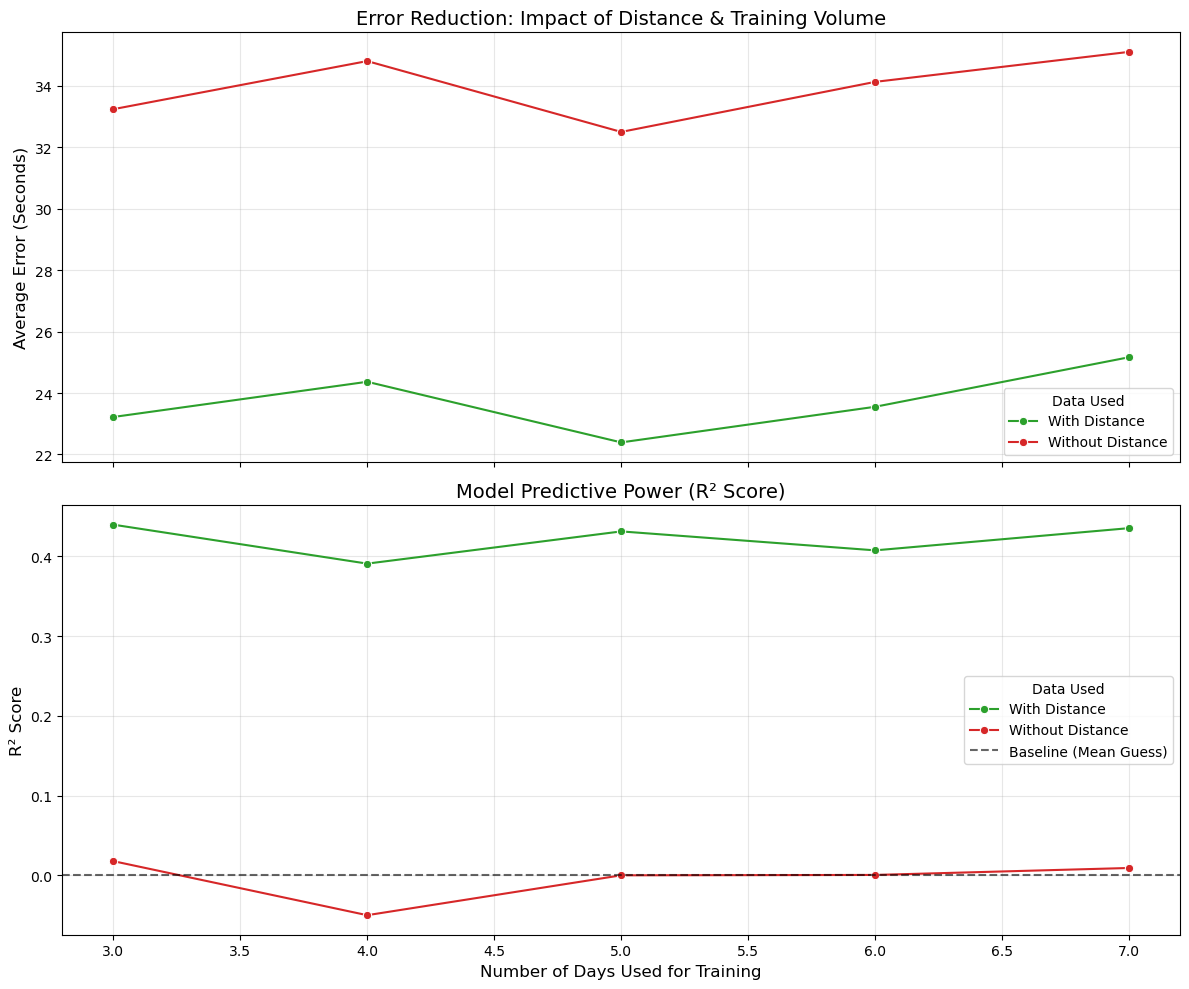

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the specific warehouse
wh_df = results_df[results_df["Warehouse"] == 'OE'].sort_values('Train_Days_Count')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Subplot 1: MAE (The "Experience" Curve) ---
sns.lineplot(data=wh_df, x='Train_Days_Count', y='MAE', hue='Scenario', 
             marker='o', ax=ax1, palette=['tab:green', 'tab:red'], errorbar=None)
ax1.set_title('Error Reduction: Impact of Distance & Training Volume', fontsize=14)
ax1.set_ylabel('Average Error (Seconds)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: R^2 (The "Quality" Benchmark) ---
sns.lineplot(data=wh_df, x='Train_Days_Count', y='R^2', hue='Scenario', 
             marker='o', ax=ax2, palette=['tab:green', 'tab:red'], errorbar=None)
# Add a baseline at 0 to explain negative R^2
ax2.axhline(0, color='black', linestyle='--', alpha=0.6, label='Baseline (Mean Guess)')
ax2.set_title('Model Predictive Power (R² Score)', fontsize=14)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_xlabel('Number of Days Used for Training', fontsize=12)
ax2.grid(True, alpha=0.3)

# Clean up legend
ax1.legend(title='Data Used')
ax2.legend(title='Data Used')

plt.tight_layout()
plt.show()

## Executive Summary: Model Performance & Insights

### 1. Model Reliability (Generalization Over Time)
By using an **Expanding Window Split** (training on days $1$ to $n$ and testing on day $n+1$), we have verified that the model generalizes effectively to new days of operation. As the training set grows, the model performance typically stabilizes, providing a reliable baseline for daily labor forecasting.

### 2. The Critical Role of Spatial Data
Our analysis confirms that **Travel Distance** and spatial context (aisle/level groupings) are the primary drivers of accuracy:
* **Accuracy Boost**: Including distance metrics reduces the average error (MAE) significantly.
* **The "Distance Penalty"**: In high-performance segments like Work Code 20, removing distance data caused the prediction error to jump from **16.60s** to **40.29s**—a **142% increase in error**.

### 3. Key Performance Benchmarks
* **High-Predictability Tasks (WC 20)**: The model explains over **63–65% of variance** ($R^2 > 0.60$) in travel time.
* **Complex Tasks (WC 30)**: Even without user-level data, the model effectively captures core trends in pick-density and location-based variance.

--- Average Performance per Scenario ---


,Warehouse,Scenario,R^2,MAE
0,OE,With Distance,0.420847,23.740000
1,OE,Without Distance,-0.004540,33.956667
2,OF,With Distance,0.491278,22.560870
3,OF,Without Distance,0.006448,36.817391



Across all test days, removing distance data increases average error by: 57.39%


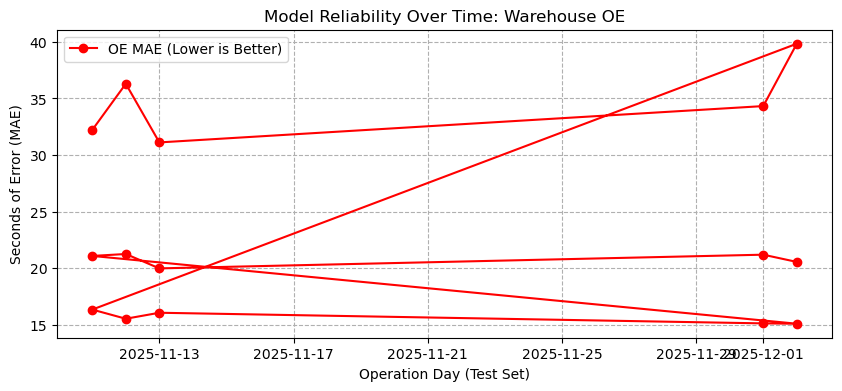

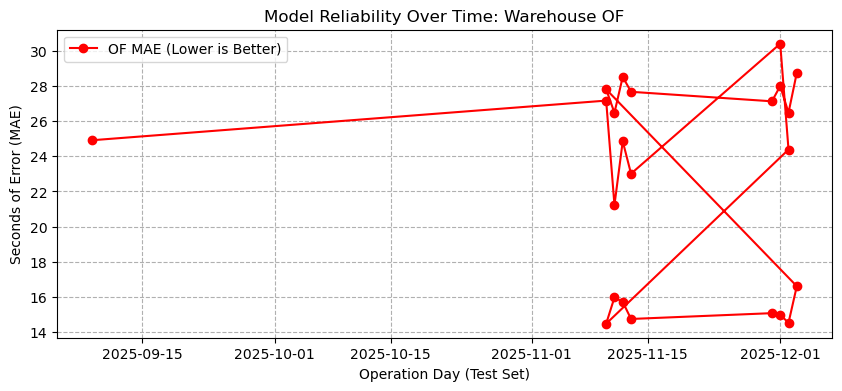

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a high-level summary table of the time-split results
summary_stats = results_df.groupby(['Warehouse', 'Scenario'])[['R^2', 'MAE']].mean().reset_index()

print("--- Average Performance per Scenario ---")
display(summary_stats)

# 2. Calculate the "Distance Impact" (ROI of Spatial Data)
# We compare 'With Distance' vs 'Without Distance' to show the % increase in error
pivot_mae = results_df.pivot_table(index=['Warehouse', 'Test_Date'], 
                                   columns='Scenario', 
                                   values='MAE')

pivot_mae['MAE_Increase_Percent'] = ((pivot_mae['Without Distance'] - pivot_mae['With Distance']) / 
                                     pivot_mae['With Distance'] * 100)

avg_penalty = pivot_mae['MAE_Increase_Percent'].mean()
print(f"\nAcross all test days, removing distance data increases average error by: {avg_penalty:.2f}%")

# 3. Visualization: Model Stability (Learning Curve)
# Filter for one warehouse to show a clean trend
for wh in results_df['Warehouse'].unique():
    wh_data = results_df[(results_df['Warehouse'] == wh) & (results_df['Scenario'] == 'With Distance')]
    
    plt.figure(figsize=(10, 4))
    plt.plot(wh_data['Test_Date'], wh_data['MAE'], marker='o', label=f'{wh} MAE (Lower is Better)', color='red')
    plt.title(f'Model Reliability Over Time: Warehouse {wh}')
    plt.xlabel('Operation Day (Test Set)')
    plt.ylabel('Seconds of Error (MAE)')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.show()

# **USING TSP OUTCOMES AS DISTANCE VARIABLE, running xgboost with this distance as a variable**

In [49]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from feature_engineer import get_engineered_df

# --- 1. TSP Heuristic (Nearest Neighbor) ---
def apply_tsp_optimization(df, dist_matrix):
    """
    Optimizes the task sequence per User/Date using a Greedy Nearest Neighbor 
    approach and returns a dataframe with recalculated travel distances.
    """
    optimized_rows = []
    # Grouping by UserID and Date to define the sequence "window"
    for (user, date), group in df.groupby(['UserID', 'Date']):
        if len(group) < 2:
            group['TSP_Distance'] = group['Travel_Distance']
            optimized_rows.append(group)
            continue
            
        locations = group['LocKey'].tolist()
        indices = group.index.tolist()
        unvisited = list(range(len(locations)))
        
        # Start at the first recorded pick of the day
        current_idx = unvisited.pop(0)
        route_indices = [indices[current_idx]]
        tsp_distances = [0.0] # First pick baseline
        
        while unvisited:
            curr_loc = locations[current_idx]
            # Find the closest unvisited location in the distance matrix
            next_idx = min(unvisited, key=lambda i: dist_matrix.loc[curr_loc, locations[i]])
            
            dist = dist_matrix.loc[curr_loc, locations[next_idx]]
            tsp_distances.append(dist)
            
            current_idx = next_idx
            route_indices.append(indices[current_idx])
            unvisited.remove(next_idx)
            
        # Reconstruct the group in optimized order while preserving original task data
        opt_group = df.loc[route_indices].copy()
        opt_group['TSP_Distance'] = tsp_distances
        
        # Update sequence-dependent flags based on the NEW sequence
        opt_group['Prev_Aisle'] = opt_group['Aisle'].shift(1)
        opt_group['same_aisle'] = (opt_group['Aisle'] == opt_group['Prev_Aisle']).astype(int)
        
        optimized_rows.append(opt_group)
        
    return pd.concat(optimized_rows)

# --- 2. Configurations ---
warehouses = ["OE"] # Starting with OE as per your tsp.ipynb
work_codes = ["30"]
max_time = 300
min_train_days = 3
all_results = []

# Load Distance Matrix
DIST_MATRIX_PATH = "../data/distance_matrices/distance_matrix_OE.csv"
dist_matrix = pd.read_csv(DIST_MATRIX_PATH, index_col=0)

for wh in warehouses:
    DATA_PATH = f"../data/processed/{wh.lower()}_detailed.parquet"
    
    for wc in work_codes:
        # Load and Engineer Features
        df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse=wh, work_code=wc, max_time=max_time)
        df['Date'] = pd.to_datetime(df['Timestamp']).dt.date
        df = df.sort_values('Timestamp')
        
        unique_dates = sorted(df['Date'].unique())
        
        # Adjust features: Swap real distance for TSP distance, remove user-level data
        model_features = [f if f != 'Travel_Distance' else 'TSP_Distance' for f in features if f != 'efficient_user']
        model_cat_cols = [c for c in cat_cols if c != 'efficient_user']

        # --- 3. Expanding Window Loop ---
        for i in range(min_train_days, len(unique_dates)):
            train_dates = unique_dates[:i]
            test_date = unique_dates[i]
            
            # Apply TSP Optimization to Train and Test separately to avoid leakage
            train_df = apply_tsp_optimization(df[df['Date'].isin(train_dates)], dist_matrix)
            test_df = apply_tsp_optimization(df[df['Date'] == test_date], dist_matrix)
            
            # Prepare X and y
            X_train = pd.get_dummies(train_df[model_features], columns=model_cat_cols, drop_first=True)
            y_train = train_df["Time_Delta_sec"]
            
            X_test = pd.get_dummies(test_df[model_features], columns=model_cat_cols, drop_first=True)
            y_test = test_df["Time_Delta_sec"]
            
            X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
            
            # Robust Model Training
            model = XGBRegressor(
                objective='reg:absoluteerror', 
                n_estimators=1000, 
                learning_rate=0.05, 
                max_depth=3, 
                min_child_weight=5, 
                random_state=42, 
                n_jobs=-1
            )
            model.fit(X_train, y_train)      

            # 4. Evaluation
            preds = model.predict(X_test)
            r2 = r2_score(y_test, preds)
            mae = mean_absolute_error(y_test, preds)
        
            all_results.append({
                    "Warehouse": wh,
                    "WorkCode": wc,
                    "Scenario": "TSP Optimized Distance",
                    "Train_End_Date": train_dates[-1],
                    "Test_Date": test_date,
                    "Train_Days_Count": len(train_dates),
                    "Train_Rows": len(X_train),
                    "Test_Rows": len(X_test),
                    "R^2": round(r2, 4),
                    "MAE": round(mae, 2)
                })
            
results_df = pd.DataFrame(all_results)
display(results_df)

,Warehouse,WorkCode,Scenario,Train_End_Date,Test_Date,Train_Days_Count,Train_Rows,Test_Rows,R^2,MAE
0,OE,30,TSP Optimized Distance,2025-11-10,2025-11-11,3,25466,6779,0.1989,23.38
1,OE,30,TSP Optimized Distance,2025-11-11,2025-11-12,4,32245,7159,0.1890,23.36
2,OE,30,TSP Optimized Distance,2025-11-12,2025-11-13,5,39404,8265,0.2270,21.90
3,OE,30,TSP Optimized Distance,2025-11-13,2025-12-01,6,47669,10765,0.1816,22.92
4,OE,30,TSP Optimized Distance,2025-12-01,2025-12-02,7,58434,6864,0.2059,22.75


/var/folders/r9/zx84vhy57q9_n8tk5dnw8g980000gn/T/ipykernel_76123/3231488241.py:10: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.lineplot(data=wh_df, x='Train_Days_Count', y='MAE', hue='Scenario',
/var/folders/r9/zx84vhy57q9_n8tk5dnw8g980000gn/T/ipykernel_76123/3231488241.py:17: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.lineplot(data=wh_df, x='Train_Days_Count', y='R^2', hue='Scenario',


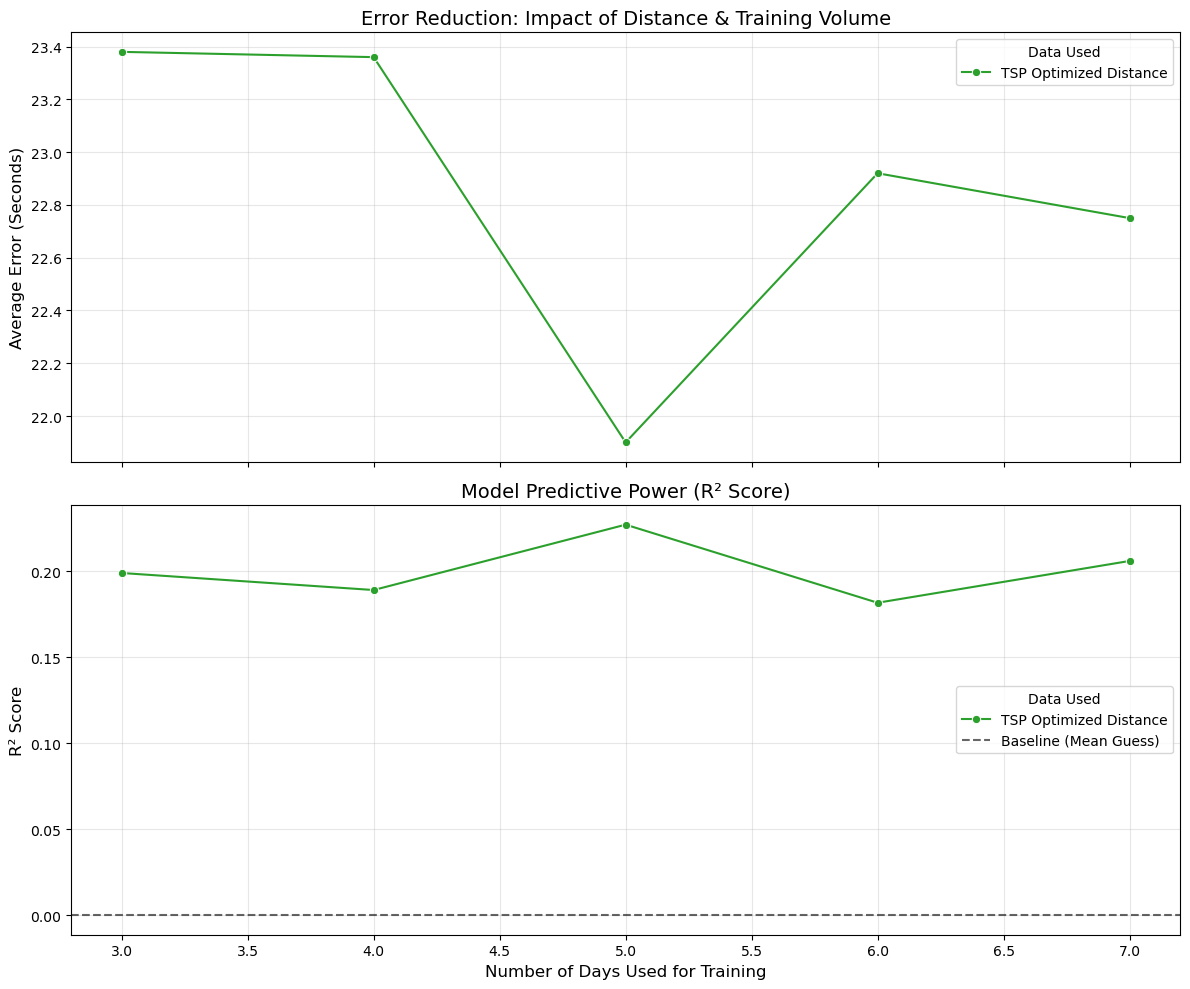

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the specific warehouse
wh_df = results_df[results_df["Warehouse"] == 'OE'].sort_values('Train_Days_Count')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Subplot 1: MAE (The "Experience" Curve) ---
sns.lineplot(data=wh_df, x='Train_Days_Count', y='MAE', hue='Scenario', 
             marker='o', ax=ax1, palette=['tab:green', 'tab:red'], errorbar=None)
ax1.set_title('Error Reduction: Impact of Distance & Training Volume', fontsize=14)
ax1.set_ylabel('Average Error (Seconds)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: R^2 (The "Quality" Benchmark) ---
sns.lineplot(data=wh_df, x='Train_Days_Count', y='R^2', hue='Scenario', 
             marker='o', ax=ax2, palette=['tab:green', 'tab:red'], errorbar=None)
# Add a baseline at 0
ax2.axhline(0, color='black', linestyle='--', alpha=0.6, label='Baseline (Mean Guess)')
ax2.set_title('Model Predictive Power (R² Score)', fontsize=14)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_xlabel('Number of Days Used for Training', fontsize=12)
ax2.grid(True, alpha=0.3)

# Clean up legend
ax1.legend(title='Data Used')
ax2.legend(title='Data Used')

plt.tight_layout()
plt.show()

# **comparing regular distance model to tsp distance**

In [53]:
all_results = []

for wh in warehouses:
    DATA_PATH = f"~/Lucas_Systems_Capstone_Project/data/processed/{wh.lower()}_detailed.parquet"
    df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse=wh, work_code=wc, max_time=max_time)
    df['Date'] = pd.to_datetime(df['Timestamp']).dt.date
    df = df.sort_values('Timestamp')
    unique_dates = sorted(df['Date'].unique())

    for i in range(min_train_days, len(unique_dates)):
        train_dates = unique_dates[:i]
        test_date = unique_dates[i]
        
        # Slicing the raw data
        raw_train = df[df['Date'].isin(train_dates)].copy()
        raw_test = df[df['Date'] == test_date].copy()
        
        # Generating the TSP versions
        tsp_train = apply_tsp_optimization(raw_train, dist_matrix)
        tsp_test = apply_tsp_optimization(raw_test, dist_matrix)

        # Focus strictly on the two distance scenarios
        scenarios = {
            "Actual Distance": {
                "train": raw_train, "test": raw_test,
                "feats": [f for f in features if f != "efficient_user"],
                "cats": [c for c in cat_cols if c != "efficient_user"]
            },
            "TSP Optimized": {
                "train": tsp_train, "test": tsp_test,
                "feats": [f if f != 'Travel_Distance' else 'TSP_Distance' for f in features if f != 'efficient_user'],
                "cats": [c for c in cat_cols if c != 'efficient_user']
            }
        }

        for name, cfg in scenarios.items():
            X_train = pd.get_dummies(cfg["train"][cfg["feats"]], columns=cfg["cats"], drop_first=True)
            y_train = cfg["train"]["Time_Delta_sec"]
            X_test = pd.get_dummies(cfg["test"][cfg["feats"]], columns=cfg["cats"], drop_first=True)
            y_test = cfg["test"]["Time_Delta_sec"]
            
            # Align columns
            X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

            # Robust Model Training
            model = XGBRegressor(objective='reg:absoluteerror', n_estimators=1000, 
                                 learning_rate=0.05, max_depth=3, min_child_weight=5, 
                                 random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            
            preds = model.predict(X_test)
            all_results.append({
                "Warehouse": wh, "WorkCode": wc, "Scenario": name,
                "Train_Days_Count": len(train_dates),
                "R^2": round(r2_score(y_test, preds), 4),
                "MAE": round(mean_absolute_error(y_test, preds), 2)
            })

results_df = pd.DataFrame(all_results)

In [55]:
results_df

,Warehouse,WorkCode,Scenario,Train_Days_Count,R^2,MAE
0,OE,30,Actual Distance,3,0.3719,21.09
1,OE,30,TSP Optimized,3,0.1989,23.38
2,OE,30,Actual Distance,4,0.3444,21.26
3,OE,30,TSP Optimized,4,0.1890,23.36
4,OE,30,Actual Distance,5,0.3716,19.99
5,OE,30,TSP Optimized,5,0.2270,21.90
6,OE,30,Actual Distance,6,0.3125,21.20
7,OE,30,TSP Optimized,6,0.1816,22.92
8,OE,30,Actual Distance,7,0.3734,20.56
9,OE,30,TSP Optimized,7,0.2059,22.75


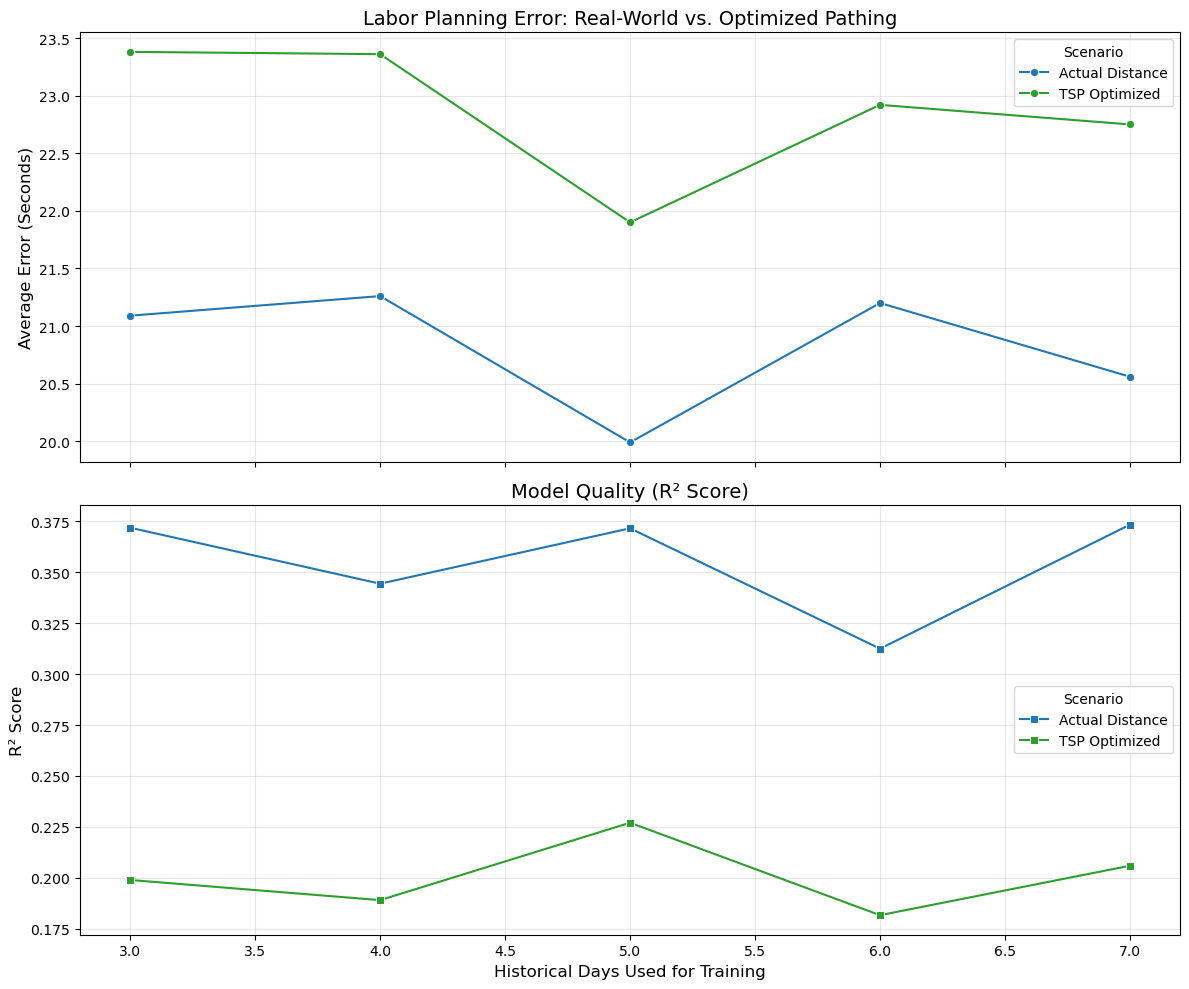

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for OE WC 30
plot_df = results_df[(results_df["Warehouse"] == 'OE') & (results_df["WorkCode"] == '30')].sort_values('Train_Days_Count')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Color Map: Blue for reality, Green for the "Optimized" goal
palette_map = {"Actual Distance": "tab:blue", "TSP Optimized": "tab:green"}

# --- Subplot 1: MAE (Accuracy Window) ---
sns.lineplot(data=plot_df, x='Train_Days_Count', y='MAE', hue='Scenario', 
             marker='o', ax=ax1, palette=palette_map, errorbar=None)
ax1.set_title('Labor Planning Error: Real-World vs. Optimized Pathing', fontsize=14)
ax1.set_ylabel('Average Error (Seconds)', fontsize=12)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: R^2 (Predictive Power) ---
sns.lineplot(data=plot_df, x='Train_Days_Count', y='R^2', hue='Scenario', 
             marker='s', ax=ax2, palette=palette_map, errorbar=None)
ax2.set_title('Model Quality (R² Score)', fontsize=14)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_xlabel('Historical Days Used for Training', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()